# Nonlinear Heat Conduction Problem with reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup


### Directories

In [2]:
import sys
from pathlib import Path
import importlib
# -----------------------------------------------------------------------------
# Project-root auto-detection script
# Ensures the top-level directory (containing 'src/' and 'tests/')
# is on Python's import path, allowing modules to be imported consistently
# regardless of the current working directory (e.g., in notebooks).
# -----------------------------------------------------------------------------

# 1) Start from the current working directory (or notebook location)
notebook_path = Path().resolve()
linear_dir = notebook_path.parent     # .../linear
# 2) Traverse upward through parent directories to find the project root
for parent in notebook_path.parents:
    # Check for indicators of the project's root structure
    if (parent / "src").exists() and (parent / "tests").exists():
        project_root = parent
        break
else:
    # If loop completes without break, no valid root was found
    raise RuntimeError(
        "Could not find project root containing 'src' and 'tests'"
    )

# 3) Prepend the detected root to sys.path to prioritize local modules
sys.path.insert(0, str(project_root))

if str(linear_dir) not in sys.path:
    sys.path.insert(0, str(linear_dir))
    
# 4) Confirm successful addition (optional print for debugging)
print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/syedabidi/Documents/GitHub/scikit-rom


### Standard Imports

In [3]:
#Standard Imports and class import
from src.skrom.utils.imports import *
from src.skrom.rom.rom_utils import *
from src.skrom.utils.reduced_basis.svd import svd_mode_selector
from src.skrom.rom.rom_error_est import *
from src.skrom.utils.visualization.color_palette import set_color_palette
import src.skrom.problem_classes.master_class_static as master
importlib.import_module("problem_1.problem_def")   # this runs @register_problem         

<module 'problem_1.problem_def' from '/Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/non_linear/problem_1/problem_def.py'>

### Plot Properties


In [4]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();

## Full Order Simulation


In [5]:
# Control flag for expensive simulation generation

generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation()
    sim.run_simulation()


TypeError: Can't instantiate abstract class ProblemNonLinear without an implementation for abstract method 'hyper_rom_solver'

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/non_linear/problem_1/ROM_data


## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


### Training Solution Snapshots


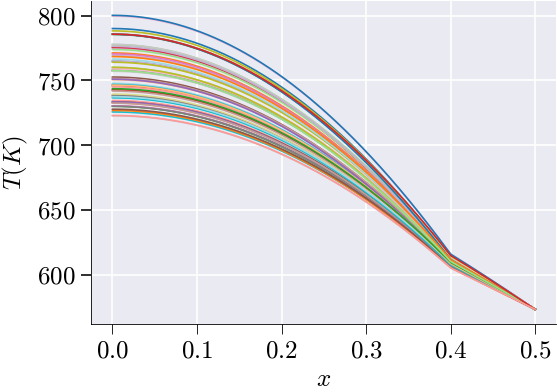

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

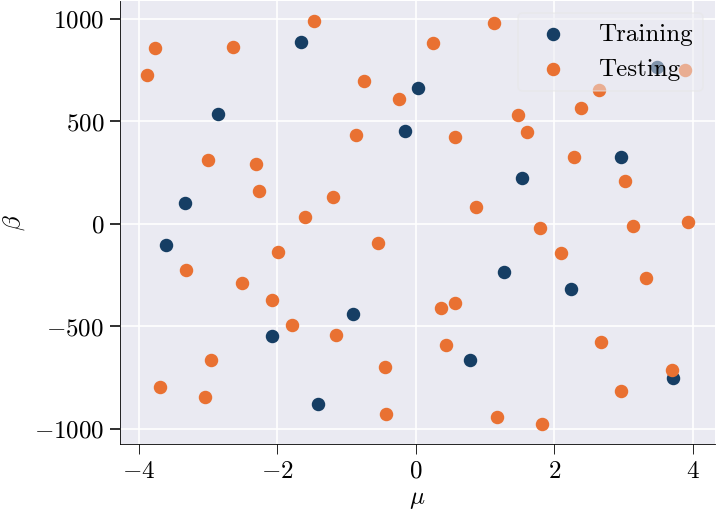

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Training Snapshots after mean subtraction

Text(0.5, 0, '$x$')

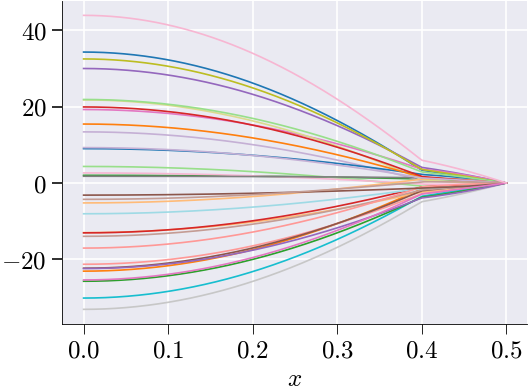

In [10]:
# Create figure with subplot for better control over the plot
fig, ax = plt.subplots(figsize=(5, 3.5))



# Extract spatial coordinates (degrees of freedom locations) from the finite element basis
# These represent the x-coordinates where the temperature values are computed
mesh_domain = sim_data['basis'].item().doflocs[0]

# Plot all mean-centered temperature profiles from the training set
for i in range(len(NLS_train_ms)):
    # Plot each mean-centered temperature fluctuation profile
    # x-axis: spatial coordinate locations (DOF locations)
    # y-axis: temperature deviation from mean (fluctuations around zero)
    # Commented line shows alternative approach using different coordinate system
    # ax.plot(d.xi[0][:-1], LS_train_ms[i])
    ax.plot(mesh_domain, NLS_train_ms[i])

# Set x-axis label with mathematical formatting
plt.xlabel('$x$')  # Spatial coordinate

### Performing SVD on training snapshots

Number of modes selected: 5


Text(0.5, 0, 'POD modes ($k$)')

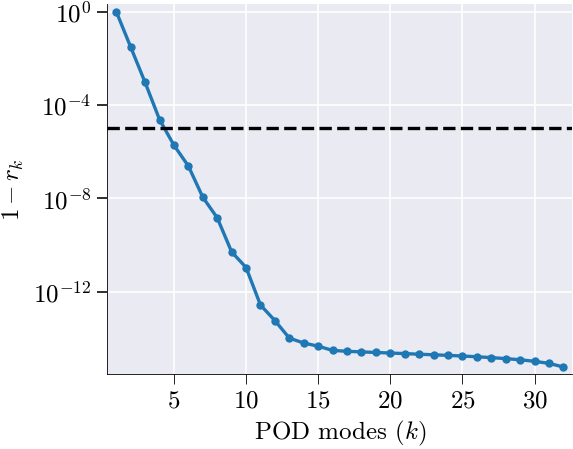

In [11]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-5,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

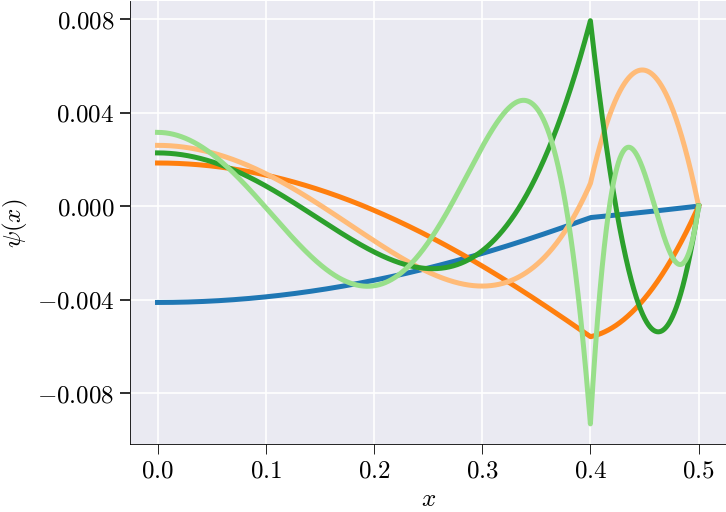

In [12]:
# Create figure and axis for POD modes visualization
fig, ax = plt.subplots()


# Plot all selected POD spatial modes
for i in range(n_sel):
    # Plot each POD mode as a function of spatial coordinate
    # x-axis: spatial locations (DOF coordinates)
    # y-axis: POD mode amplitude at each spatial location
    # lw=3: Use thick lines for better visibility of mode shapes
    plt.plot(mesh_domain, V_sel[:, i], lw=3)

# Set axis labels with mathematical notation
ax.set_xlabel('$x$')        # Spatial coordinate
ax.set_ylabel('$\\psi(x)$')  # POD mode amplitude (basis function value)

# Control the number of y-axis ticks for cleaner appearance
# nbins=5: Limit to approximately 5 major tick marks on y-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Display the plot
plt.show()

## ROM Simulation


In [13]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from /Users/syedabidi/Documents/GitHub/scikit-rom/tests/heat_transfer/static/non_linear/problem_1/ROM_data


In [14]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[  3.88820642 750.09545498]
[Newton] Iter  0, step norm = 5.772e+03
[Newton] Iter  1, step norm = 1.366e+01
[Newton] Iter  2, step norm = 9.265e-05
Snap 2/64 params=[  -2.95594767 -666.10105895]
[Newton] Iter  0, step norm = 1.133e+04
[Newton] Iter  1, step norm = 7.075e+01
[Newton] Iter  2, step norm = 2.806e-03
Snap 3/64 params=[ -0.86523633 431.5031115 ]
[Newton] Iter  0, step norm = 3.198e+03
[Newton] Iter  1, step norm = 4.781e+00
[Newton] Iter  2, step norm = 1.463e-05
Snap 4/64 params=[  1.79043026 -19.36559565]
[Newton] Iter  0, step norm = 6.040e+03
[Newton] Iter  1, step norm = 1.381e+01
[Newton] Iter  2, step norm = 9.592e-05
Snap 5/64 params=[ 0.87346801 79.66099493]
[Newton] Iter  0, step norm = 1.819e+03
[Newton] Iter  1, step norm = 1.373e+00
[Newton] Iter  2, step norm = 1.683e-06
Snap 6/64 params=[  -1.78225864 -495.71905099]
[Newton] Iter  0, step norm = 4.666e+03
[Newton] Iter  1, step norm = 1.097e+01
[Newton] Iter  2, step norm = 7.065e-05
Snap 7/6

In [15]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 2.0703e-02
Relative L2 Error:        1.4725e-08
L∞ Error:                 6.4763e-05
Relative L∞ Error:        8.0932e-08
RMSE:                     1.0109e-05
MAE:                      6.3471e-06

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -7.0427e-09
95th Percentile Error:    1.8527e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 1.1007e-08
Max Rel L2 Error over time/parameter: 5.1172e-08
Min Rel L2 Error over time/parameter: 5.6889e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

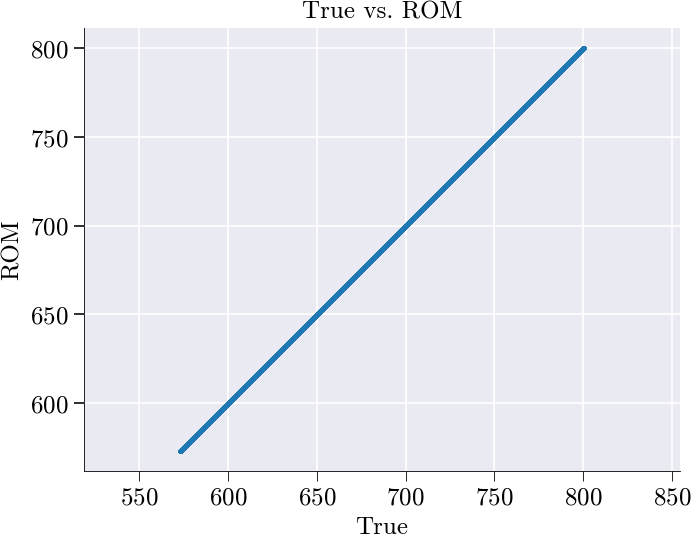

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


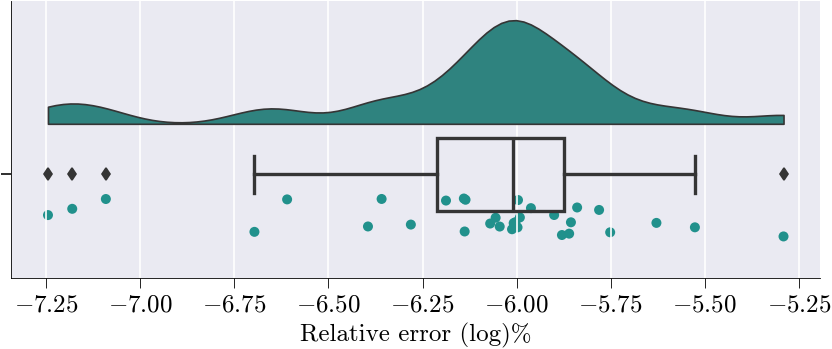

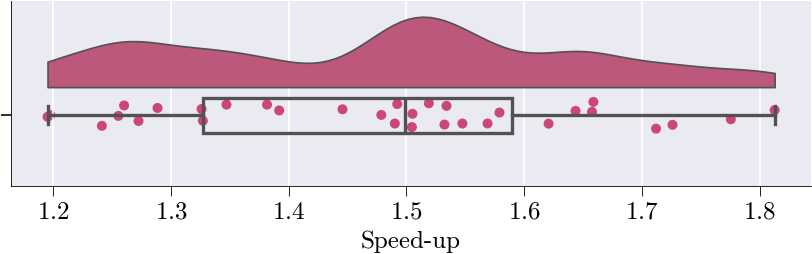

In [16]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)
